In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_angles)=
# Get angles

*Getting angles between specific triplets of atoms in a molecular system.*

The function {func}`molsysmt.structure.get_angles` computes valence bond angles or angles between specified triplets of atoms across one or more structures or trajectory frames.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.structure.get_angles`.
:::


## Basic usage

Let's calculate the valence angle formed by atoms `[0, 1, 2]` across a pentalanine trajectory:


In [2]:
import molsysmt as msm
import numpy as np
import matplotlib.pyplot as plt


In [3]:
molsys = msm.convert(msm.systems['pentalanine']['traj_pentalanine.h5'], to_form='molsysmt.MolSys')


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We inspect the atom names and residue identity of the triplet `[0, 1, 2]`:


In [4]:
msm.info(molsys, element='atom', selection=[0, 1, 2])


index,id,name,type,group index,group id,group name,group type,component index,chain index,molecule index,molecule type,entity index,entity name
0,None,H1,H,0,1,ACE,terminal capping,0,0,0,peptide,0,peptide 0
1,None,CH3,C,0,1,ACE,terminal capping,0,0,0,peptide,0,peptide 0
2,None,H2,H,0,1,ACE,terminal capping,0,0,0,peptide,0,peptide 0


We compute the angle values along the 5000 simulation frames:


In [5]:
angles = msm.structure.get_angles(molsys, [0, 1, 2])
angles_deg = msm.pyunitwizard.convert(angles, to_unit='degrees')


In [6]:
print('Angles shape:', angles.shape)
print('Mean angle:', np.mean(angles_deg))


Angles shape: (5000, 1)
Mean angle: 109.24924838747883 degree


We plot the angle time evolution across the trajectory:


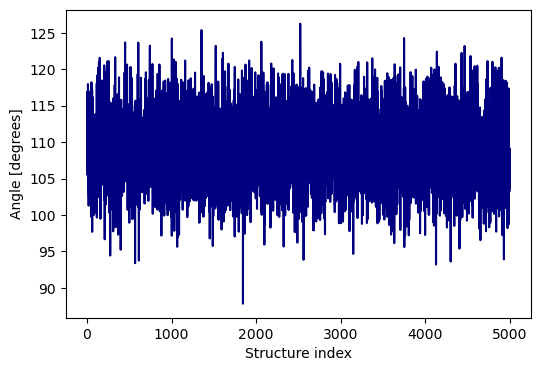

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(angles_deg[:, 0], color='navy')
plt.xlabel('Structure index')
plt.ylabel('Angle [degrees]')
plt.show()


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Info <Tutorial_Info>`: Inspect summary information and atom properties with {func}`molsysmt.basic.info`.
- {ref}`Get dihedral angles <Tutorial_Get_dihedral_angles>`: Compute dihedral/torsion angles with {func}`molsysmt.structure.get_dihedral_angles`.
- {ref}`Get distances <Tutorial_Get_distances>`: Measure pairwise distances between atoms with {func}`molsysmt.structure.get_distances`.
:::
